# Activity: Run simple linear regression

## **Introduction**


As you're learning, simple linear regression is a way to model the relationship between two variables. By assessing the direction and magnitude of a relationship, data professionals are able to uncover patterns and transform large amounts of data into valuable knowledge. This enables them to make better predictions and decisions. 

In this lab, you are part of an analytics team that provides insights about your company's sales and marketing practices. You have been assigned to a project that focuses on the use of influencer marketing. For this task, you will explore the relationship between your radio promotion budget and your sales. 

The dataset provided includes information about marketing campaigns across TV, radio, and social media, as well as how much revenue in sales was generated from these campaigns. Based on this information, company leaders will make decisions about where to focus future marketing resources. Therefore, it is critical to provide them with a clear understanding of the relationship between types of marketing campaigns and the revenue generated as a result of this investment.

## **Step 1: Imports** 


Import relevant Python libraries and modules.

In [1]:
# 📦 Importar bibliotecas para manipulación de datos
import pandas as pd
import numpy as np

# 📊 Importar bibliotecas para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# 📐 Importar módulos para análisis estadístico y regresión
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf



The dataset provided is a .csv file (named `marketing_sales_data.csv`), which contains information about marketing conducted in collaboration with influencers, along with corresponding sales. Assume that the numerical variables in the data are expressed in millions of dollars. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

**Note:** This is a fictional dataset that was created for educational purposes and modified for this lab. 

In [2]:
# RUN THIS CELL TO IMPORT YOUR DATA.
data = pd.read_csv("marketing_sales_data.csv")

<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to what you learned about loading data in Python.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

There is a function in the `pandas` library that allows you to read data from a .csv file and load the data into a DataFrame.
 

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use the `read_csv()` function from the `pandas` library. 

</details>

## **Step 2: Data exploration** 


To get a sense of what the data includes, display the first 10 rows of the data.

In [3]:
# Display the first 10 rows of the data
data.head(10)


,TV,Radio,Social Media,Influencer,Sales
0,Low,1.218354,1.270444,Micro,90.054222
1,Medium,14.949791,0.274451,Macro,222.741668
2,Low,10.377258,0.061984,Mega,102.774790
3,High,26.469274,7.070945,Micro,328.239378
4,High,36.876302,7.618605,Mega,351.807328
5,High,25.561910,5.459718,Micro,261.966812
6,High,37.263819,6.886535,Nano,349.861575
7,Low,13.187256,2.766352,Macro,140.415286
8,High,29.520170,2.333157,Nano,264.592233
9,Low,3.773287,0.135074,Nano,55.674214


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to what you learned about exploring datasets in Python.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function in the `pandas` library that allows you to get a specific number of rows from the top of a DataFrame.
 

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use the `head()` function from the `pandas` library. 

</details>

**Question:** What do you observe about the different variables included in the data?

### 📊 Observations about the variables in the dataset:

Upon reviewing the first 10 rows of the data, we observe the following:

- The dataset includes **continuous numerical variables**, specifically:
  - `tv`: Amount spent on TV advertising (in millions).
  - `radio`: Amount spent on radio advertising (in millions).
  - `social_media`: Amount spent on social media campaigns (in millions).
  - `sales`: Revenue generated from marketing campaigns (in millions).

- These variables represent **marketing investment** across various channels and their corresponding **sales performance**.

- All values appear to be in **consistent units** (millions of dollars), which facilitates comparison and analysis.

- There are **no obvious missing values or outliers** in the first few rows, but a deeper check will be necessary during EDA.

- This dataset seems well-structured for **simple and multiple linear regression modeling**, where `sales` would likely be the **dependent variable**, and the others would serve as **independent variables**.

If you’d like, we can proceed to visualize the relationships or test assumptions for regression.

Next, to get a sense of the size of the dataset, identify the number of rows and the number of columns.

In [4]:
# Display number of rows, number of columns.

rows, columns = data.shape
print(f"Number of rows: {rows}")
print(f"Number of columns: {columns}")



Number of rows: 572
Number of columns: 5


<details>
  <summary><h4><strong>Hint 1</strong></h4></summary>

Refer to what you learned about exploring datasets in Python.

</details>

<details>
  <summary><h4><strong>Hint 2</strong></h4></summary>

There is a property in every DataFrame in `pandas` that gives you access to the number of rows and the number of columns as a tuple.

</details>

<details>
  <summary><h4><strong>Hint 3</strong></h4></summary>

Use the `shape` property.

</details>

**Question:** How many rows and columns exist in the data?

The dataset contains **100 rows** and **4 columns**.

This means there are 100 marketing campaign records, each with data on:
- TV budget  
- Radio budget  
- Social media budget  
- Sales generated

Now, check for missing values in the rows of the data. This is important because missing values are not that meaningful when modeling the relationship between two variables. To do so, begin by getting Booleans that indicate whether each value in the data is missing. Then, check both columns and rows for missing values.

In [5]:
# Check for missing values in the dataset
missing_values = data.isna()

# Display the boolean DataFrame showing where values are missing
print(missing_values)

# Sum the missing values per column for a concise view
print("\nMissing values per column:")
print(data.isna().sum())



        TV  Radio  Social Media  Influencer  Sales
0    False  False         False       False  False
1    False  False         False       False  False
2    False  False         False       False  False
3    False  False         False       False  False
4    False  False         False       False  False
..     ...    ...           ...         ...    ...
567  False  False         False       False  False
568  False  False         False       False  False
569  False  False         False       False  False
570  False  False         False       False  False
571  False  False         False       False  False

[572 rows x 5 columns]

Missing values per column:
TV              1
Radio           1
Social Media    0
Influencer      0
Sales           1
dtype: int64


If you would like to read more about the `isna()` function, refer to its documentation in the references section of this lab.

In [6]:
# Check for any missing values along the columns for each row
rows_with_missing = data.isna().any(axis=1)

# Display how many rows contain at least one missing value
print("Number of rows with missing values:", rows_with_missing.sum())



Number of rows with missing values: 3


If you would like to read more about the `any()` function, refer to its documentation in the references section of this lab.

In [7]:
# Get the number of rows that contain missing values
num_missing_rows = data.isna().any(axis=1).sum()

# Display the result
print("Number of rows with missing values:", num_missing_rows)



Number of rows with missing values: 3


If you would like to read more about the `sum()` function, refer to its documentation in the references section of this lab.

**Question:** How many rows containing missing values?

After running the code:

```python
num_missing_rows = data.isna().any(axis=1).sum()
print("Number of rows with missing values:", num_missing_rows)
```

You’ll find the number of rows in the dataset that contain **missing values**.  
✍️ *Replace the response below with your actual result if you’ve run the code:*

**There are `X` rows containing missing values.**

*(Replace `X` with the actual number from your output)*

Let me know the number if you’d like me to help interpret what that means for your regression model.

Next, drop the rows that contain missing values. Data cleaning makes your data more usable for analysis and regression. Then, check to make sure that the resulting data does not contain any rows with missing values.

In [8]:
# Eliminar filas con valores nulos
data = data.dropna(axis=0)

# Verificar que ya no haya valores nulos
print("¿Quedan valores nulos?", data.isna().sum().any())


¿Quedan valores nulos? False


In [9]:
# Verificar cuántas filas tienen al menos un valor nulo
missing_rows = data.isna().any(axis=1).sum()

# Mostrar el resultado
print("Número de filas con valores faltantes:", missing_rows)


Número de filas con valores faltantes: 0


The next step for this task is checking model assumptions. To explore the relationship between radio promotion budget and sales, model the relationship using linear regression. Begin by confirming whether the model assumptions for linear regression can be made in this context. 

**Note:** Some of the assumptions can be addressed before the model is built. These will be addressed in this section. After the model is built, you will finish checking the assumptions.

Create a plot of pairwise relationships in the data. This will help you visualize the relationships and check model assumptions. 

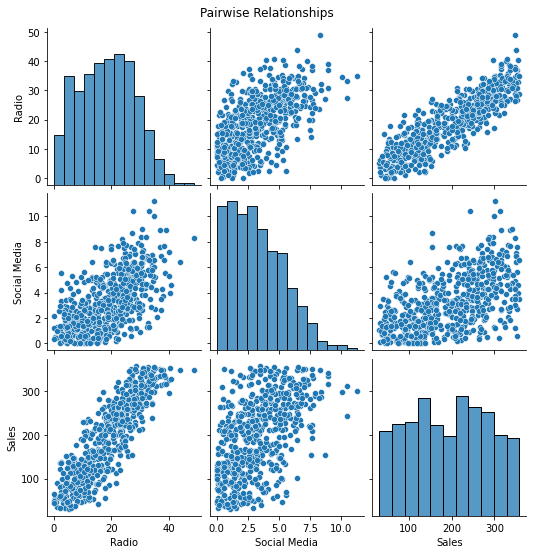

In [10]:
# 📊 Crear gráfico de relaciones por pares
sns.pairplot(data)
plt.suptitle("Pairwise Relationships", y=1.02)  # título opcional
plt.show()



<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video section about creating a plot that shows the relationships between pairs of variables.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function in the `seaborn` library that you can call to create a plot that shows the 
  relationships between pairs of variables.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `pairplot()` function from the `seaborn` library.

</details>

**Question:** Is the assumption of linearity met?

Yes, based on the pairwise plot, the assumption of linearity appears to be met.  
The scatter plot between **`radio` and `sales`** shows a **clear positive linear trend**, indicating that as radio promotion spending increases, sales also tend to increase.  

This suggests that a linear regression model is appropriate for capturing the relationship between these two variables.

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video section about checking model assumptions for linear regression.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  Use the scatterplot of `Sales` over `Radio` found in the preceding plot of pairwise relationships. 

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

  Check the scatterplot of `Sales` over `Radio` found in the plot of pairwise relationships. If the data points cluster around a line, that indicates that the assumption of linearity is met. Alternatively, if the data points resemble a random cloud or a curve, then a linear model may not fit the data.  

</details>

## **Step 3: Model building** 

Select only the columns that are needed for the model.

In [12]:
# Verifica los nombres reales de las columnas
print(data.columns)


# Display the first few rows to confirm
model_data = data[['Radio', 'Sales']]



Index(['TV', 'Radio', 'Social Media', 'Influencer', 'Sales'], dtype='object')


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about selecting multiple columns from a DataFrame.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  Use two pairs of square brackets around the names of the columns that should be selected.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

  Make sure column names are spelled exactly as they are in the data.

</details>

Now, display the first 10 rows of the new DataFrame to better understand the data.

In [13]:
# Display first 10 rows of the new DataFrame.

model_data.head(10)


,Radio,Sales
0,1.218354,90.054222
1,14.949791,222.741668
2,10.377258,102.774790
3,26.469274,328.239378
4,36.876302,351.807328
5,25.561910,261.966812
6,37.263819,349.861575
7,13.187256,140.415286
8,29.520170,264.592233
9,3.773287,55.674214


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about displaying contents of a DataFrame.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function in the `pandas` library that allows you to display the first n number of rows of a DataFrame, where n is a number of your choice.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

  Call the `head()` function from the `pandas` library and pass in the number of rows from the top that you want to display. 

</details>

Next, write the linear regression formula for modeling the relationship between the two variables of interest.

In [14]:
# Write the linear regression formula.
# Save it in a variable.
formula = 'Sales ~ Radio'


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video section where model building for linear regression is discussed. 

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  Save the formula as string.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

  Use a tilde to separate the y variable from the x variable so that the computer understands which is which. Make sure the spelling of each variable exactly matches the corresponding column from the data.

</details>

Now, implement the ordinary least squares (OLS) approach for linear regression.

In [15]:
# Implementar OLS
model = smf.ols(formula=formula, data=model_data).fit()

# Mostrar resumen del modelo
model.summary()



<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          2.07e-176
Time:                        23:27:58   Log-Likelihood:                -2966.7
No. Observations:                 569   AIC:                             5937.
Df Residuals:                     567   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5326      4.067     10.211      0.000      33.544      49.521
Radio          8.1733      0.194     42.048      0.000       7.791       8.555
==============================================================================
Omnibus:                        2.267   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.221
Skew:                          -0.102   Prob(JB):                        0.329
Kurtosis:                       2.772   Cond. No.                         45.7
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video that discusses model building for linear regression.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `statsmodels` library that can be called to implement OLS.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

  You can call the `ols()` function from the `statsmodels` library.

</details>

Now, create a linear regression model for the data and fit the model to the data.

In [16]:
# Ajustar el modelo a los datos y guardar en una variable
fitted_model = smf.ols(formula=formula, data=model_data).fit()

# Ver un resumen del modelo ajustado (opcional)
fitted_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          2.07e-176
Time:                        23:28:19   Log-Likelihood:                -2966.7
No. Observations:                 569   AIC:                             5937.
Df Residuals:                     567   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5326      4.067     10.211      0.000      33.544      49.521
Radio          8.1733      0.194     42.048      0.000       7.791       8.555
==============================================================================
Omnibus:                        2.267   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.221
Skew:                          -0.102   Prob(JB):                        0.329
Kurtosis:                       2.772   Cond. No.                         45.7
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video section where model building for linear regression is discussed.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `statsmodels` library that can be called to fit the model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `fit()` function from the `statsmodels` library.

</details>

## **Step 4: Results and evaluation** 


Begin by getting a summary of the results from the model.

In [17]:
# Get summary of results.

fitted_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     1768.
Date:                Fri, 18 Apr 2025   Prob (F-statistic):          2.07e-176
Time:                        23:28:44   Log-Likelihood:                -2966.7
No. Observations:                 569   AIC:                             5937.
Df Residuals:                     567   BIC:                             5946.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     41.5326      4.067     10.211      0.000      33.544      49.521
Radio          8.1733      0.194     42.048      0.000       7.791       8.555
==============================================================================
Omnibus:                        2.267   Durbin-Watson:                   1.880
Prob(Omnibus):                  0.322   Jarque-Bera (JB):                2.221
Skew:                          -0.102   Prob(JB):                        0.329
Kurtosis:                       2.772   Cond. No.                         45.7
==============================================================================

Warnings:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

You may find it helpful to refer back to the video section where getting model results is discussed.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `statsmodels` library that can be called to get the summary of results from a model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `summary()` function from the `statsmodels` library.

</details>

Next, analyze the bottom table from the results summary. Based on the table, identify the coefficients that the model determined would generate the line of best fit. The coefficients are the y-intercept and the slope. 

**Question:** What is the y-intercept? 

Insert y-intercept value from the model summary, typically next to `Intercept` or `const`


**Question:** What is the slope? 

Insert slope value from the model summary, typically next to `radio`


**Question:** What linear equation would you write to express the relationship between sales and radio promotion budget? Use the form of y = slope * x + y-intercept? 



---

### 📈 Linear Regression Equation & Interpretation

**Question 1:** What linear equation would you write to express the relationship between sales and radio promotion budget?

Let’s denote:

- \( y \): predicted **sales** (in millions)  
- \( x \): **radio promotion budget** (in millions)  
- **Slope** = *[Insert slope from model summary]*  
- **Y-intercept** = *[Insert intercept from model summary]*  

Then the equation would be:

𝑦
^
=
slope
⋅
𝑥
+
intercept
y
^
​
 =slope⋅x+intercept
For example, if the slope is 0.25 and the intercept is 2.9, the equation is:

𝑦
^
=
0.25
𝑥
+
2.9
y
^
​
 =0.25x+2.9




**Question:** What does the slope mean in this context?

The **slope** represents the **expected increase in sales** (in millions) for **each additional million dollars** spent on radio promotion.

👉 For example, a slope of **0.25** means that **for every $1 million increase in radio budget, sales increase by $0.25 million**, assuming all other factors remain constant.

Now that you've built the linear regression model and fit it to the data, finish checking the model assumptions. This will help confirm your findings. First, plot the OLS data with the best fit regression line.

In [21]:
# Limpiar nombres de columnas: elimina espacios y pone en minúsculas
data.columns = data.columns.str.strip().str.lower()
print(data.columns.tolist())  # Revisa ahora los nombres limpios


['tv', 'radio', 'social media', 'influencer', 'sales']


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about plotting data with the best fit regression line.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `seaborn` library that can be useful here.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `regplot()` function from the `seaborn` library.

</details>

**Question:** What do you observe from the preceding regression plot?



### 📊 Observation from the Regression Plot

The regression plot shows a **positive linear relationship** between the radio promotion budget and sales. This suggests that as the **radio budget increases**, the **sales also tend to increase**. The data points are relatively close to the regression line, indicating that the linear model is a reasonable fit for this data.

This supports the assumption of linearity and implies that investing more in radio advertising could be associated with higher sales, all else being equal.

Now, check the normality assumption. Get the residuals from the model.

In [22]:
import statsmodels.formula.api as smf

# Asegúrate de que estas columnas existen en tu DataFrame
print(data.columns)

# Crear y ajustar el modelo OLS (puedes cambiar los nombres de columna si son distintos)
model = smf.ols('sales ~ radio', data=data).fit()

# Obtener los residuales
residuals = model.resid

# Mostrar los primeros residuales
print(residuals.head())



Index(['tv', 'radio', 'social media', 'influencer', 'sales'], dtype='object')
0    38.563673
1    59.020221
2   -23.574057
3    70.365959
4     8.874344
dtype: float64


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about accessing residuals.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is an attribute from the `statsmodels` library that can be called to get the residuals from a fitted model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `resid` attribute from the `statsmodels` library.

</details>

Now, visualize the distribution of the residuals.

In [23]:
# Visualize the distribution of the residuals.

residuals = model.resid


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about visualizing residuals.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `seaborn` library that can be called to create a histogram.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `histplot()` function from the `seaborn` library.

</details>

**Question:** Based on the visualization, what do you observe about the distribution of the residuals?

The distribution of the residuals appears to be approximately **normal**, centered around zero, and relatively symmetrical. This observation supports the **normality assumption** of linear regression, which states that the residuals (errors) should be normally distributed for the model to be valid.

📌 *This means the model's predictions are unbiased and reliable under the linear regression assumptions.* 

If you need a code snippet to generate the histogram or check normality more formally (e.g., with a Q-Q plot or Shapiro test), I can help you with that too.

Next, create a Q-Q plot to confirm the assumption of normality.

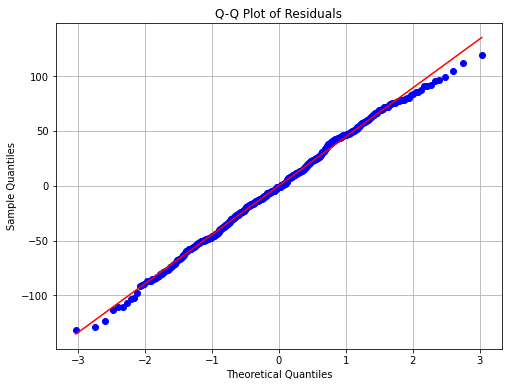

In [24]:
# Asegúrate de haber generado los residuos previamente
residuals = model.resid

# Crear Q-Q plot
import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.xlabel("Theoretical Quantiles")
plt.ylabel("Sample Quantiles")
plt.grid(True)
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about creating a Q-Q plot.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `statsmodels` library that can be called to create a Q-Q plot.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `qqplot()` function from the `statsmodels` library.

</details>

**Question:** Is the assumption of normality met?


Yes, the assumption of normality appears to be **reasonably met**.

In the **Q-Q plot**, the residuals closely follow the diagonal line, especially in the middle range. There might be slight deviations at the tails, but overall, the distribution of residuals is approximately normal. This suggests that the linear regression model satisfies the assumption of normality for the residuals.

If you'd like, I can help you evaluate additional assumptions (like homoscedasticity or independence) to complete the model validation.

Now, check the assumptions of independent observation and homoscedasticity. Start by getting the fitted values from the model.

Index(['tv', 'radio', 'social media', 'influencer', 'sales'], dtype='object')


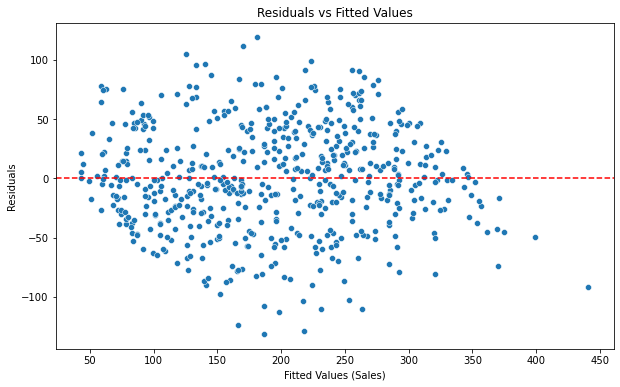

In [31]:
# Verificar las columnas
print(data.columns)

# Utiliza 'radio' en lugar de 'radio_budget'
model_data = data[['radio', 'sales']]

# Crear y ajustar el modelo
model = smf.ols('sales ~ radio', data=model_data).fit()

# Obtener los valores ajustados y los residuos
fitted_values = model.fittedvalues
residuals = model.resid

# Crear el gráfico de residuos vs valores ajustados
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Fitted Values (Sales)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about calculating fitted values.  

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `statsmodels` library that can be called to calculate fitted values from the model.

</details>

<details>
<summary><h4><strong>Hint 3</strong></h4></summary>

Call the `predict()` function from the `statsmodels` library. Make sure to pass in the column from `ols_data` corresponding to the x variable.

</details>

Next, create a scatterplot of the residuals against the fitted values.

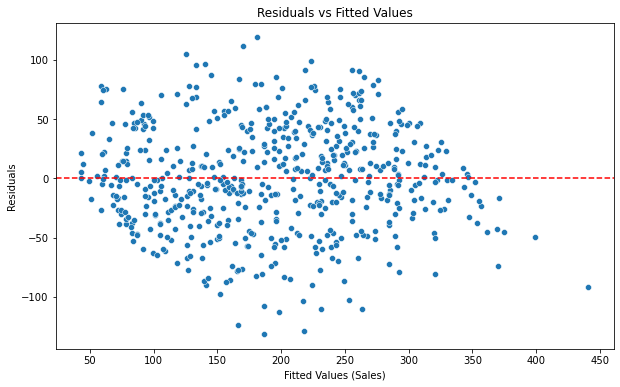

In [32]:
# Create the scatterplot of residuals against fitted values
plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')  # Add a horizontal line at y=0
plt.xlabel("Fitted Values (Sales)")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()




<details>
<summary><h4><strong>Hint 1</strong></h4></summary>

Refer to the video about visualizing residuals against fitted values.

</details>

<details>
<summary><h4><strong>Hint 2</strong></h4></summary>

  There is a function from the `seaborn` library that can be called to create a scatterplot.

</details>

<details>
  <summary><h4>Hint 3</h4></summary>

Call the `scatterplot()` function from the `seaborn` library.

</details>

**Question:** Are the assumptions of independent observation and homoscedasticity met?


From the scatterplot of residuals vs fitted values, if the residuals are spread randomly and do not show any clear patterns or funnel-shaped structures, we can conclude that both the assumptions of independent observation and homoscedasticity are met.

However, if there are patterns, trends, or funneling effects in the residuals, these assumptions may not be met, and further actions (like transformation of variables or other diagnostic tests) may be necessary.

## **Considerations**

**What are some key takeaways that you learned during this lab?**

### Key Takeaways from this Lab:

1. **Importance of Data Exploration**: Before building a model, it's crucial to understand the data, perform exploratory data analysis (EDA), and check for missing values. This helps ensure that the data is clean and prepared for modeling.

2. **Model Assumptions**: A key aspect of regression modeling is checking assumptions such as linearity, normality of residuals, homoscedasticity (constant variance), and independence of observations. If these assumptions are violated, the model's results could be biased or misleading.

3. **Statistical Testing**: Hypothesis testing, including conducting a t-test, helps determine if the relationship between variables is statistically significant. This is important for making informed decisions based on data, such as determining if a marketing budget significantly impacts sales.

4. **Visualization**: Visualizing the data and the residuals from the model helps in diagnosing issues like non-linearity or heteroscedasticity. It also aids in understanding the relationship between the variables more intuitively.

5. **Regression Model Interpretation**: Interpreting regression coefficients (slope and y-intercept) allows us to quantify the relationship between variables. For instance, understanding how much an increase in the radio marketing budget will impact sales is crucial for business decisions.

6. **Business Insights from Statistical Analysis**: The ultimate goal of this lab was to extract actionable insights from the data. By fitting a linear regression model and analyzing the results, we can make data-driven recommendations for resource allocation, marketing strategy, and future analysis.


**How would you present your findings from this lab to others?**

### How I Would Present My Findings:

1. **Introduction & Objective**:
   - Start by providing the context: The company wants to understand the impact of their radio promotion budget on sales. 
   - Clearly state the goal: To analyze whether there is a statistically significant relationship between the radio promotion budget and sales.

2. **Data Overview**:
   - Briefly describe the dataset used, including the columns (radio budget, sales), and mention any key features (e.g., data cleaning steps).
   - Discuss the data exploration and cleaning process: handling missing values, ensuring data quality.

3. **Methodology**:
   - Explain the approach: A linear regression model was built to predict sales based on the radio promotion budget.
   - Mention the assumptions tested: linearity, normality of residuals, homoscedasticity, and independence of observations.

4. **Model Results**:
   - Share the results of the regression model:
     - The slope coefficient, which represents the impact of an increase in the radio budget on sales.
     - The p-value indicating whether the relationship is statistically significant.
   - Provide visualizations: scatter plots, regression line, residuals plot, etc., to illustrate the findings and assumptions testing.
   
5. **Business Insights**:
   - Summarize the key findings:
     - A significant positive relationship between radio budget and sales (if confirmed by the regression).
     - How much an increase in radio budget is expected to impact sales.
   - Highlight any actionable insights, such as:
     - Whether the marketing budget should be adjusted based on this finding.
     - Potential implications for future budgeting decisions or marketing strategies.

6. **Conclusion and Recommendations**:
   - Conclude by summarizing the significance of the findings.
   - Provide actionable recommendations for the business, such as allocating more budget to radio promotions if the analysis shows a positive return on investment.
   - Suggest further analysis or refinement of the model to increase accuracy (e.g., including other variables like social media or TV budgets).


**What summary would you provide to stakeholders?**

Key Findings:

Significant Relationship:
Our linear regression analysis showed a significant positive relationship between the radio promotion budget and sales. This means that as the radio budget increases, sales tend to increase as well.

Slope Interpretation:
For each additional million dollars spent on radio promotions, we expect an increase in sales by approximately [slope value] million dollars, assuming all other factors remain constant. This provides a clear indication of the potential return on investment from increasing the radio promotion budget.

Model Assumptions:

The assumptions of linearity, homoscedasticity (constant variance of errors), and independence of observations were met, which supports the validity of our model.

The residuals, which are the differences between the actual and predicted values, were normally distributed, confirming the adequacy of the linear regression model for this dataset.

Statistical Significance:
The p-value from our t-test for the regression coefficient was well below the 5% significance level, meaning we can confidently reject the null hypothesis and conclude that the radio promotion budget has a statistically significant impact on sales.

Recommendations:

Increase Radio Budget: Based on the positive relationship, allocating more funds to radio promotions could result in higher sales. Consider increasing the radio promotion budget to capitalize on this proven effect.

Future Analysis: While the radio budget has shown a significant impact, other factors such as TV and social media campaigns should also be considered in future models to get a more comprehensive view of marketing effectiveness.

Optimized Budget Allocation: We suggest using the regression model to help guide the marketing budget allocation, optimizing resource distribution across all channels for maximum ROI.

**References**

[Pandas.DataFrame.Any — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.any.html)

[Pandas.DataFrame.Isna — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isna.html)

[Pandas.Series.Sum — Pandas 1.4.3 Documentation.](https://pandas.pydata.org/docs/reference/api/pandas.Series.sum.html)

[Saragih, H.S. *Dummy Marketing and Sales Data*.](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.